# Decision Trees — 2-Hour Hands-On Practical Session
### Classification & Regression on Synthetic Tabular Datasets

## 0. Import Libraries

In [1]:
# Core data handling
import numpy as np                                     # numerical arrays
import pandas as pd                                     # DataFrames

# Plotting
import matplotlib.pyplot as plt                          # base plotting
import seaborn as sns                                    # nicer statistical plots
sns.set_style("whitegrid")                                # clean plot background

# Synthetic scikit-learn dataset generators (all generated locally, no internet needed)
from sklearn.datasets import make_classification, make_moons, make_friedman1

# Preprocessing & splitting
from sklearn.model_selection import train_test_split       # train/test split
# Note: Decision Trees do NOT require feature scaling (splits are threshold-based,
# not distance-based) — so we skip StandardScaler in this notebook.

# Decision Tree models
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

RANDOM_STATE = 42   # fixed seed used everywhere for reproducibility

print("Libraries imported successfully.")

Libraries imported successfully.


---
## Part 1 — Decision Tree Classification

We generate a **tabular** classification dataset locally using `make_classification`:
1,000 samples, 10 numeric features, and 3 classes. This mimics a realistic tabular
business/scientific dataset (e.g. customer segments, product categories) without relying
on any external file or image data.


### 1.1 Generate the Dataset

In [2]:
# Generate a synthetic multi-class tabular dataset
# n_informative: features that actually carry signal about the class
# n_redundant: features that are linear combinations of informative ones (adds realism)
X_cls, y_cls = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=3,
    n_clusters_per_class=1,
    random_state=RANDOM_STATE
)

print("Data shape:", X_cls.shape)
print("Target shape:", y_cls.shape)
print("Possible classes:", np.unique(y_cls))

Data shape: (1000, 10)
Target shape: (1000,)
Possible classes: [0 1 2]


In [29]:
X_cls

array([[ 0.37303163, -1.13489178,  0.9022714 , ..., -2.22575637,
        -1.78595586,  0.0082055 ],
       [-0.51964573, -1.07426482,  0.46082487, ..., -1.71982387,
        -0.58030266, -0.41317648],
       [-1.36292857, -0.38207637,  0.9693693 , ..., -2.81059907,
        -1.42695669, -1.64756308],
       ...,
       [-0.81921648,  1.88720478, -0.993593  , ...,  1.59438154,
         0.87946007, -1.04248741],
       [-1.20136796,  2.98853595,  0.08409439, ...,  0.20478032,
        -3.78934367, -4.61378881],
       [-0.98340144, -1.41392741,  0.46643129, ...,  1.06251401,
        -0.08598455, -0.1514632 ]])

In [3]:
# Combine features + target into a DataFrame for easy exploration
feature_names = [f"feature_{i+1}" for i in range(X_cls.shape[1])]
class_df = pd.DataFrame(X_cls, columns=feature_names)
class_df["class"] = y_cls

class_df.head()   # preview the first 5 rows

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,class
0,0.373032,-1.134892,0.902271,0.051089,0.994352,-1.825443,0.147208,-2.225756,-1.785956,0.008205,2
1,-0.519646,-1.074265,0.460825,1.765754,-1.963289,1.131813,0.057753,-1.719824,-0.580303,-0.413176,0
2,-1.362929,-0.382076,0.969369,0.942034,-0.221781,0.556081,1.294150,-2.810599,-1.426957,-1.647563,0
3,0.670373,-0.170700,-0.050801,1.449404,-0.057397,1.925280,-0.442750,-0.638952,0.197736,0.144873,1
4,-1.595769,2.316428,-2.104583,-3.156789,-0.308960,0.979722,0.713157,1.368373,2.593543,-0.318854,1


### 1.2 Explore the Dataset

In [4]:
print(class_df.shape)          # (rows, columns)
class_df.info()                 # column dtypes + non-null counts

(1000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   1000 non-null   float64
 1   feature_2   1000 non-null   float64
 2   feature_3   1000 non-null   float64
 3   feature_4   1000 non-null   float64
 4   feature_5   1000 non-null   float64
 5   feature_6   1000 non-null   float64
 6   feature_7   1000 non-null   float64
 7   feature_8   1000 non-null   float64
 8   feature_9   1000 non-null   float64
 9   feature_10  1000 non-null   float64
 10  class       1000 non-null   int32  
dtypes: float64(10), int32(1)
memory usage: 82.2 KB


In [5]:
# Summary statistics for all features
class_df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,class
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.994193,0.625790,-0.018871,-0.371626,-0.018979,0.423618,0.307538,-0.227975,-0.310324,-0.952440,1.000000
std,1.125968,2.207179,1.020855,1.725885,1.053468,1.677120,1.646462,1.894920,1.803915,1.748908,0.817722
min,-4.931075,-8.442295,-3.688365,-5.558615,-3.221016,-5.614509,-4.692490,-5.723717,-6.626081,-6.616267,0.000000
25%,-1.720624,-0.820972,-0.718129,-1.570453,-0.737644,-0.505202,-0.706228,-1.520845,-1.490339,-1.947982,0.000000
50%,-0.976799,0.755492,-0.032160,-0.372921,-0.058133,0.587145,0.321703,-0.294238,-0.328682,-0.793461,1.000000
75%,-0.285605,2.054027,0.684208,0.947968,0.741819,1.563674,1.351696,1.105957,0.852276,0.239857,2.000000
max,2.695232,7.301062,3.529055,4.584841,2.943048,5.066045,5.806373,6.008868,5.379806,4.197874,2.000000


In [6]:
# How many samples per class? (checking class balance)
class_df["class"].value_counts().sort_index()

class
0    334
1    332
2    334
Name: count, dtype: int64

### 1.3 Visualize the Dataset

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating ins

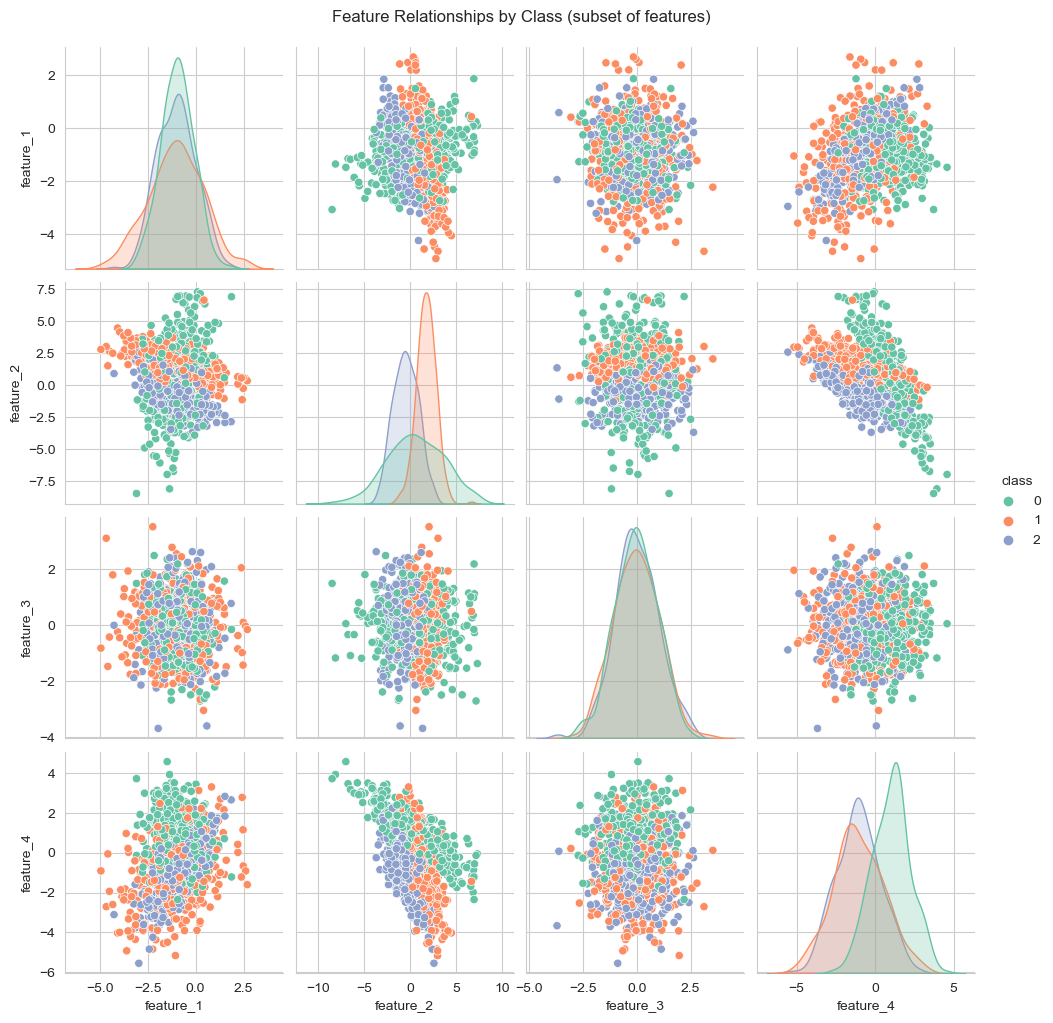

In [7]:
# Pairplot on a handful of features, colored by class (all 10 would be too dense to read)
sns.pairplot(class_df, hue="class", vars=["feature_1", "feature_2", "feature_3", "feature_4"], palette="Set2")
plt.suptitle("Feature Relationships by Class (subset of features)", y=1.02)
plt.show()

### 1.4 Train-Test Split

In [8]:
# Split into training (80%) and testing (20%) sets
# stratify=y_cls keeps the same class proportions in both splits
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

print("Training samples:", X_train_cls.shape[0])
print("Testing samples:", X_test_cls.shape[0])

Training samples: 800
Testing samples: 200


### 1.5 Train a Decision Tree Classifier (default settings)

In [9]:
# Create a Decision Tree classifier (unrestricted depth by default)
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Fit the tree on the training data
dt_clf.fit(X_train_cls, y_train_cls)

print("Decision Tree classifier trained.")
print("Tree depth reached:", dt_clf.get_depth())
print("Number of leaves:", dt_clf.get_n_leaves())

Decision Tree classifier trained.
Tree depth reached: 12
Number of leaves: 75


### 1.6 Make Predictions

In [10]:
# Predict class labels for the test set
y_pred_cls = dt_clf.predict(X_test_cls)

# Compare actual vs predicted labels side-by-side
comparison_df = pd.DataFrame({
    "Actual": y_test_cls,
    "Predicted": y_pred_cls
})
comparison_df.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,1,1
4,1,0
5,0,0
6,2,2
7,0,0
8,1,1
9,1,1


In [11]:
# predict_proba gives the model's confidence (fraction of leaf samples) for each class
proba_cls = dt_clf.predict_proba(X_test_cls)

proba_df = pd.DataFrame(proba_cls, columns=[f"class_{i}" for i in range(3)])
proba_df.head()

,class_0,class_1,class_2
0,0.0,1.0,0.0
1,0.0,1.0,0.0
2,1.0,0.0,0.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0


### 1.7 Visualize the Trained Tree (Top Levels)

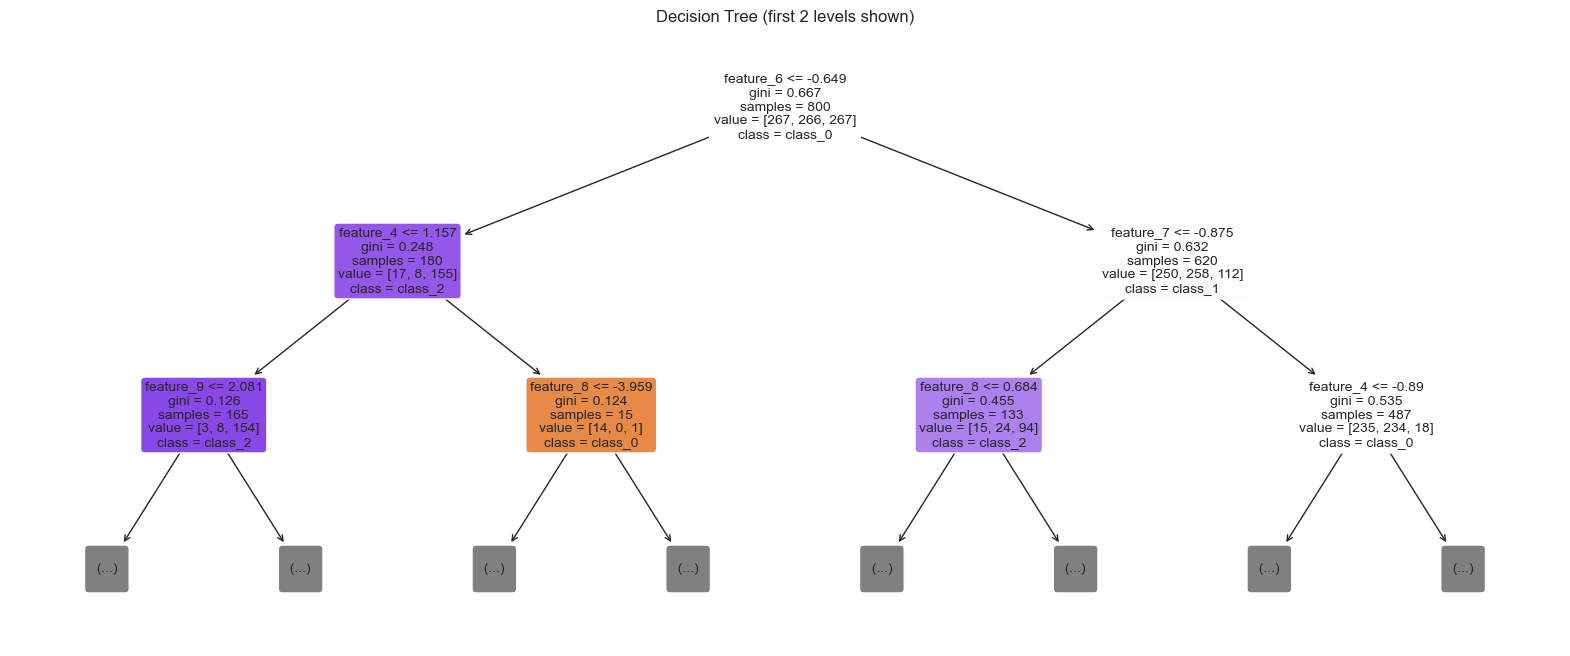

In [12]:
# A full tree can be large, so we only display the first few levels for clarity
plt.figure(figsize=(20, 8))
plot_tree(
    dt_clf,
    max_depth=2,                 # only show the first 2 levels of splits
    feature_names=feature_names,
    class_names=[f"class_{i}" for i in range(3)],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (first 2 levels shown)")
plt.show()

### 1.8 Predict a Brand-New Sample

In [13]:
# Grab one sample directly from the test set to simulate a "new" incoming record
new_sample = X_test_cls[0].reshape(1, -1)

predicted_class = dt_clf.predict(new_sample)
print("Predicted class:", predicted_class[0])
print("Actual class was:", y_test_cls[0])

Predicted class: 1
Actual class was: 1


### 1.9 Trying Different `max_depth` Values

`max_depth` controls how many levels of splits the tree is allowed to make. Let's train
several trees with different depths and compare their predictions on the same test
samples.


In [14]:
# List of max_depth values to try (None = unlimited depth)
depth_values = [1, 2, 3, 5, 10, None]

predictions_by_depth = {}
for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train_cls, y_train_cls)
    preds = model.predict(X_test_cls)
    predictions_by_depth[f"depth={depth}"] = preds

# Build a comparison table: rows = first 10 test samples, columns = predictions per depth
depth_comparison_df = pd.DataFrame(predictions_by_depth).head(10)
depth_comparison_df.insert(0, "Actual", y_test_cls[:10])
depth_comparison_df

,Actual,depth=1,depth=2,depth=3,depth=5,depth=10,depth=None
0,1,1,0,1,1,1,1
1,1,1,2,1,1,1,1
2,0,1,0,0,1,0,0
3,1,1,0,1,1,1,1
4,1,1,0,0,1,0,0
5,0,1,0,0,0,0,0
6,2,2,2,2,2,2,2
7,0,1,0,0,0,0,0
8,1,1,0,1,1,1,1
9,1,1,2,1,1,1,1


### 1.10 Visualize How Decision Boundaries Change with `max_depth`

To make the decision boundary itself visible, we switch to a classic 2D synthetic dataset
(`make_moons`) — two interleaving, non-linearly-separable crescents. This is a great way
to see exactly how a Decision Tree carves up 2D space.


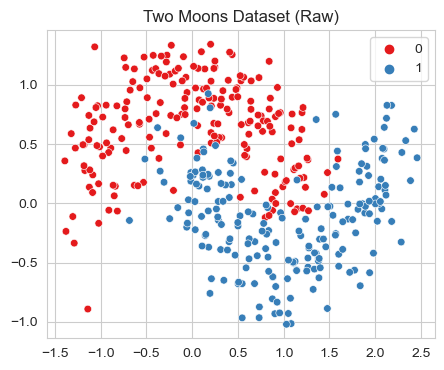

In [15]:
# Generate a 2D "two moons" dataset — a classic nonlinear benchmark for classifiers
X_moons, y_moons = make_moons(n_samples=400, noise=0.25, random_state=RANDOM_STATE)

X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=RANDOM_STATE, stratify=y_moons
)

# Quick look at the raw shape before fitting any trees
plt.figure(figsize=(5, 4))
sns.scatterplot(x=X_moons[:, 0], y=X_moons[:, 1], hue=y_moons, palette="Set1", s=30)
plt.title("Two Moons Dataset (Raw)")
plt.show()

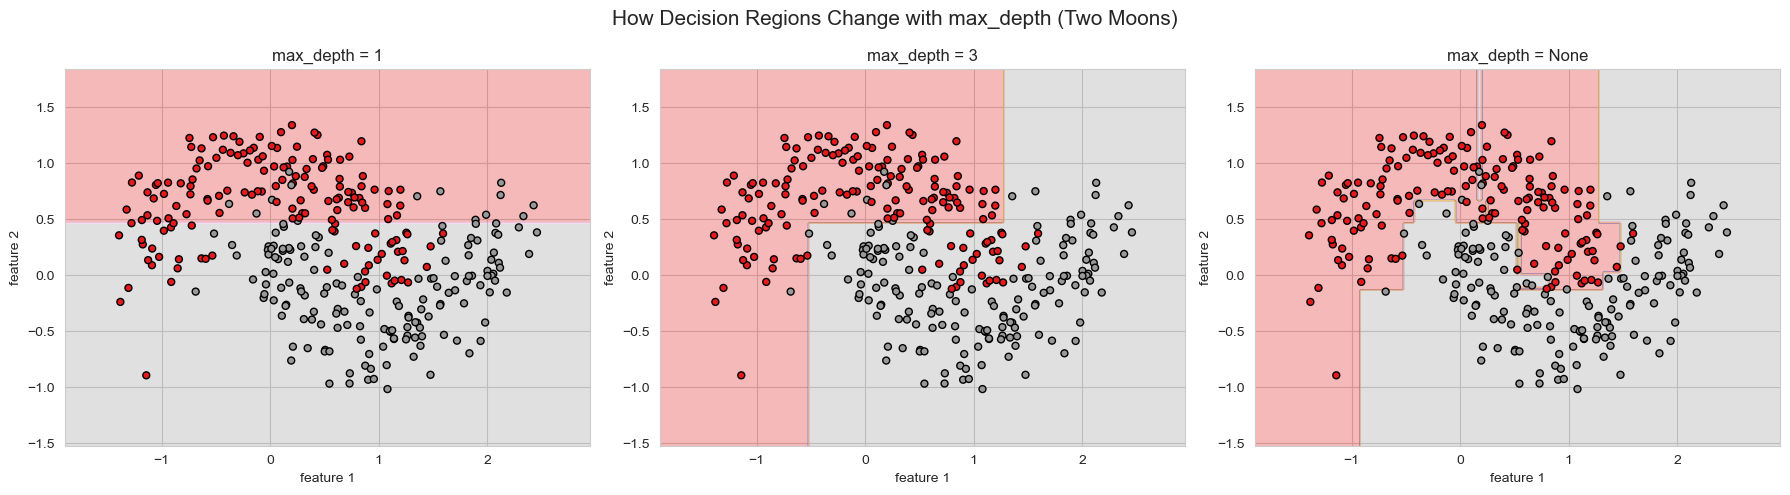

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, depth in zip(axes, [1, 3, None]):
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train_moons, y_train_moons)

    # Build a mesh grid over the 2D feature space to show decision regions
    x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
    y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap="Set1")
    ax.scatter(X_train_moons[:, 0], X_train_moons[:, 1], c=y_train_moons, cmap="Set1",
               edgecolor="black", s=25)
    ax.set_title(f"max_depth = {depth}")
    ax.set_xlabel("feature 1")
    ax.set_ylabel("feature 2")

plt.suptitle("How Decision Regions Change with max_depth (Two Moons)", fontsize=15)
plt.tight_layout()
plt.show()

**Observation:** A shallow tree (`max_depth=1`) makes very simple, blocky splits.
As depth increases, the regions become more complex and fit the training data more
closely (an unlimited-depth tree can carve out very intricate, tiny regions around
individual points).


---
## Part 2 — Decision Tree Regression (Synthetic Nonlinear Dataset)

We generate a dataset locally using `make_friedman1`, a well-known synthetic benchmark:
the target is a **nonlinear combination** of 5 input features (plus noise). It's a great
way to show that Decision Trees can model nonlinear relationships without any feature
engineering.


### 2.1 Generate the Dataset

In [17]:
# Generate 300 samples with 5 features; only the first 5 features actually influence y
# (this is the standard Friedman #1 formula built into scikit-learn)
X_fr, y_fr = make_friedman1(n_samples=300, n_features=5, noise=1.0, random_state=RANDOM_STATE)

print("X shape:", X_fr.shape)
print("y shape:", y_fr.shape)

X shape: (300, 5)
y shape: (300,)


In [18]:
# Combine into a DataFrame for easy exploration
friedman_df = pd.DataFrame(X_fr, columns=[f"feature_{i+1}" for i in range(X_fr.shape[1])])
friedman_df["target"] = y_fr

friedman_df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,0.374540,0.950714,0.731994,0.598658,0.156019,14.338856
1,0.155995,0.058084,0.866176,0.601115,0.708073,14.808768
2,0.020584,0.969910,0.832443,0.212339,0.181825,4.480117
3,0.183405,0.304242,0.524756,0.431945,0.291229,5.886480
4,0.611853,0.139494,0.292145,0.366362,0.456070,10.479942


### 2.2 Explore the Dataset

In [19]:
print(friedman_df.shape)
friedman_df.info()

(300, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_1  300 non-null    float64
 1   feature_2  300 non-null    float64
 2   feature_3  300 non-null    float64
 3   feature_4  300 non-null    float64
 4   feature_5  300 non-null    float64
 5   target     300 non-null    float64
dtypes: float64(6)
memory usage: 14.2 KB


In [20]:
friedman_df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,0.509504,0.505776,0.492707,0.509662,0.479138,14.435238
std,0.298556,0.292839,0.290620,0.293076,0.295688,5.271110
min,0.009197,0.004632,0.005522,0.005062,0.011621,0.989226
25%,0.237470,0.241424,0.228596,0.259101,0.218084,10.937843
50%,0.515851,0.520825,0.503966,0.520041,0.480824,14.388844
75%,0.787654,0.767890,0.746736,0.756610,0.725812,18.296384
max,0.992965,0.999718,0.996874,0.996334,0.999414,29.492074


### 2.3 Visualize Relationships

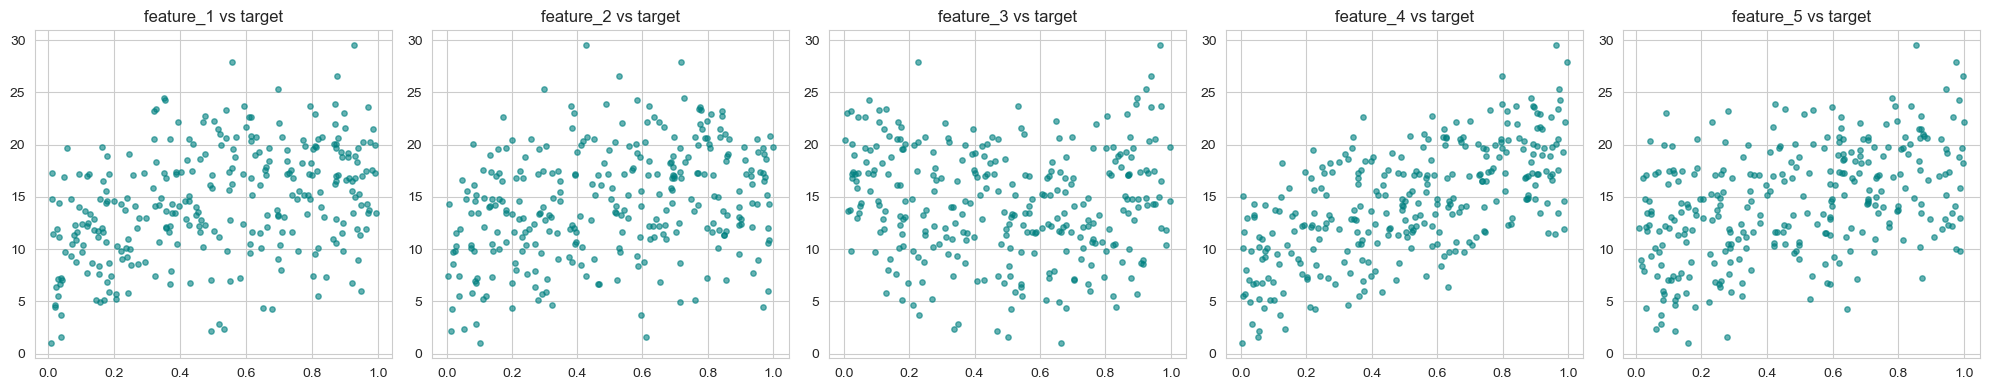

In [21]:
# Scatter plots of each feature against the target
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, friedman_df.columns[:-1]):
    ax.scatter(friedman_df[col], friedman_df["target"], s=15, alpha=0.6, color="teal")
    ax.set_title(f"{col} vs target")
plt.tight_layout()
plt.show()

### 2.4 A Simple 1-Feature Demo: Visualizing How `max_depth` Shapes the Fit

Before using all 5 features, let's build intuition with just **one feature**
(`feature_1`) predicting the `target`, so we can literally see the tree's step-like
prediction curve.


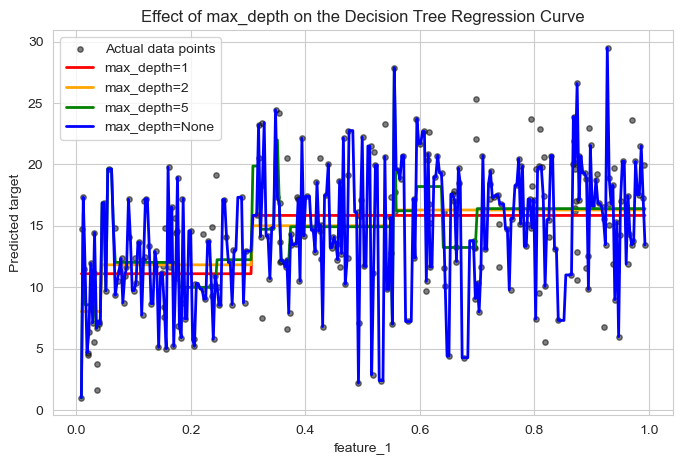

In [22]:
# Single feature for a clean 1D visualization
X_single = friedman_df[["feature_1"]].values
y_single = friedman_df["target"].values

# Create a smooth range of x-values to draw the prediction curve
x_range = np.linspace(X_single.min(), X_single.max(), 300).reshape(-1, 1)

plt.figure(figsize=(8, 5))
plt.scatter(X_single, y_single, color="black", s=15, alpha=0.5, label="Actual data points")

# Overlay prediction curves for a few different max_depth values
for depth, color in zip([1, 2, 5, None], ["red", "orange", "green", "blue"]):
    reg_demo = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    reg_demo.fit(X_single, y_single)
    y_curve = reg_demo.predict(x_range)
    plt.plot(x_range, y_curve, label=f"max_depth={depth}", color=color, linewidth=2)

plt.xlabel("feature_1")
plt.ylabel("Predicted target")
plt.title("Effect of max_depth on the Decision Tree Regression Curve")
plt.legend()
plt.show()

**Observation:** With `max_depth=1`, the tree can only make **one split**, producing
a simple two-step function. As depth increases, the tree adds more steps, fitting the data
more tightly (an unlimited-depth tree can create a step for nearly every point).


### 2.5 Full Regression: Train-Test Split

In [23]:
# Use all 5 features to predict the target
X_reg = friedman_df.drop(columns=["target"]).values
y_reg = friedman_df["target"].values

# Split into train (80%) / test (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print("Training samples:", X_train_reg.shape[0])
print("Testing samples:", X_test_reg.shape[0])

Training samples: 240
Testing samples: 60


### 2.6 Train a Decision Tree Regressor (max_depth = 4)

In [24]:
# Create and fit a Decision Tree regressor with a modest max_depth to avoid overfitting
dt_reg = DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE)
dt_reg.fit(X_train_reg, y_train_reg)

print("Decision Tree regressor trained.")
print("Tree depth reached:", dt_reg.get_depth())
print("Number of leaves:", dt_reg.get_n_leaves())

Decision Tree regressor trained.
Tree depth reached: 4
Number of leaves: 16


### 2.7 Make Predictions

In [25]:
# Predict target values for the test samples
y_pred_reg = dt_reg.predict(X_test_reg)

# Compare actual vs predicted values
reg_comparison_df = pd.DataFrame({
    "Actual target": np.round(y_test_reg, 2),
    "Predicted target": np.round(y_pred_reg, 2)
})
reg_comparison_df.head(10)

,Actual target,Predicted target
0,13.46,16.29
1,27.87,20.83
2,11.74,13.72
3,13.30,16.29
4,10.07,12.56
5,19.46,12.56
6,14.18,12.56
7,12.16,11.73
8,13.33,16.29
9,4.99,5.46


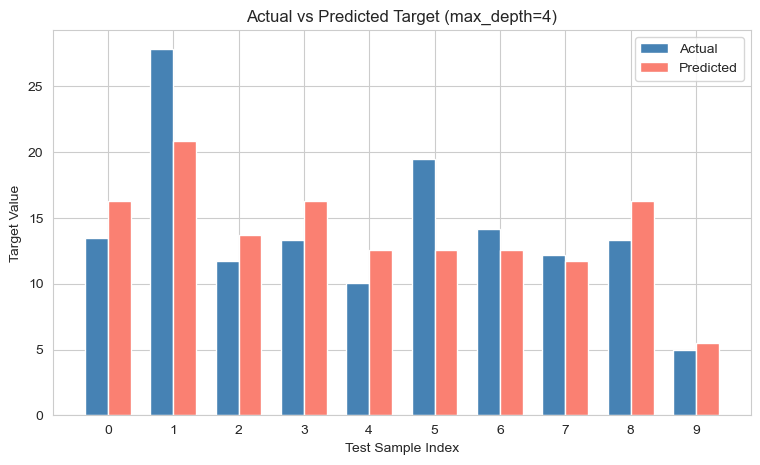

In [26]:
# Visualize actual vs predicted as a simple bar comparison for the first 10 test samples
x_pos = np.arange(10)
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x_pos - width/2, y_test_reg[:10], width, label="Actual", color="steelblue")
plt.bar(x_pos + width/2, y_pred_reg[:10], width, label="Predicted", color="salmon")
plt.xlabel("Test Sample Index")
plt.ylabel("Target Value")
plt.title("Actual vs Predicted Target (max_depth=4)")
plt.xticks(x_pos)
plt.legend()
plt.show()

### 2.8 Predict on a Brand-New Data Point

In [27]:
# A new, unseen 5-feature input
new_point = np.array([[0.5, 0.3, 0.8, 0.2, 0.6]])

predicted_value = dt_reg.predict(new_point)
print("Predicted target value:", round(predicted_value[0], 3))

Predicted target value: 8.855


### 2.9 Trying Different `max_depth` Values for Regression

In [28]:
# List of max_depth values to try
depth_values_reg = [1, 2, 3, 5, 8, None]

predictions_by_depth_reg = {}
for depth in depth_values_reg:
    model = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train_reg, y_train_reg)
    preds = model.predict(X_test_reg)
    predictions_by_depth_reg[f"depth={depth}"] = np.round(preds[:10], 2)

depth_comparison_reg_df = pd.DataFrame(predictions_by_depth_reg)
depth_comparison_reg_df.insert(0, "Actual", np.round(y_test_reg[:10], 2))
depth_comparison_reg_df

,Actual,depth=1,depth=2,depth=3,depth=5,depth=8,depth=None
0,13.46,15.95,17.28,19.12,15.38,16.39,16.82
1,27.87,15.95,17.28,19.12,22.66,21.86,21.68
2,11.74,15.95,12.59,15.37,12.95,14.50,14.56
3,13.30,15.95,17.28,19.12,15.38,12.45,14.59
4,10.07,8.68,9.58,10.76,11.26,11.26,11.65
5,19.46,8.68,9.58,10.76,14.18,16.80,13.25
6,14.18,8.68,9.58,10.76,14.18,13.97,13.73
7,12.16,15.95,17.28,14.66,14.06,13.59,13.43
8,13.33,15.95,17.28,19.12,15.38,16.39,14.08
9,4.99,8.68,9.58,6.14,4.68,4.92,5.18


---
## 5. Effect of `max_depth` — Quick Takeaways

- **Shallow tree (e.g. depth=1–2)** → very simple splits, may **underfit** (miss patterns).
- **Deep / unlimited tree** → can fit training data very closely, including noise
  (risk of **overfitting**), and produces jagged step-like predictions.
- Other controls with a similar effect: `min_samples_split`, `min_samples_leaf`,
  `max_leaf_nodes` (all limit how much the tree can grow).
- The **best depth is usually found by experimentation** (covered with proper evaluation
  metrics in the next session).


---
## 6. Practice Exercises (Try During the Session)

1. Generate the classification dataset with `n_samples=500` instead of 1000 and print how
   many samples belong to each class using `value_counts()`.
2. Create a scatter plot of `feature_1` vs `feature_2`, colored by class.
3. Split the classification data into 70% train / 30% test instead of 80/20.
4. Train a `DecisionTreeClassifier` with `max_depth=4` and predict the class for the first
   5 test samples.
5. Using the Friedman synthetic dataset, create a scatter plot of `feature_3` vs `target`.
6. Train a `DecisionTreeRegressor` with `max_depth=6` on the Friedman dataset and predict
   the target for a new point `[0.1, 0.9, 0.4, 0.7, 0.2]`.
7. Change the `criterion` parameter of `DecisionTreeClassifier` to `"entropy"` (instead of
   the default `"gini"`) and compare predictions on the same test samples.


## 7. Coding Assignments (More Involved)

**Assignment 1 — Feature Importances**
Train a `DecisionTreeClassifier` on the full classification dataset and inspect
`.feature_importances_`. Write code to print the **top 3 most important features**
(highest importance values) along with their names.

**Assignment 2 — Depth Sweep Table**
Write a loop that trains a `DecisionTreeClassifier` for every `max_depth` from 1 to 15 on
the classification training data, and store each model's **prediction on a single fixed
test sample** in a list. Print how many different predicted classes appear across all
depths for that one sample.

**Assignment 3 — Minimum Samples per Leaf**
Retrain the classifier using `DecisionTreeClassifier(min_samples_leaf=10,
random_state=42)` instead of the default. Compare the resulting tree's depth and number
of leaves with the unrestricted version from Section 1.5.

**Assignment 4 — Full Tree Visualization**
Using `plot_tree`, visualize the **entire** tree (no `max_depth` limit on the plot) for a
`DecisionTreeClassifier(max_depth=3, random_state=42)` trained on the classification
dataset. Identify which feature is used for the very first (root) split.

**Assignment 5 — Regression Tree Depth vs Leaf Count**
For the Friedman regression dataset, write code to loop over `max_depth = 1 to 10`, train
a `DecisionTreeRegressor` at each depth, and print a table of `depth -> number of leaves`.
